In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

In [ ]:
data = pd.read_csv("/content/global_cancer_patients_2015_2024.csv")

In [ ]:
data

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,PT0049995,80,Male,Pakistan,2023,2.3,7.5,2.8,3.8,2.9,Leukemia,Stage 0,71463.70,1.0,3.63
49996,PT0049996,40,Female,USA,2018,6.4,3.5,2.9,9.0,9.8,Colon,Stage I,49619.66,0.4,6.03
49997,PT0049997,74,Male,Pakistan,2015,6.2,1.6,8.7,4.7,4.0,Breast,Stage 0,5338.25,2.7,6.02
49998,PT0049998,21,Male,Brazil,2018,4.0,6.5,7.6,8.6,8.1,Liver,Stage IV,45100.47,7.5,6.54


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             50000 non-null  object 
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   Country_Region         50000 non-null  object 
 4   Year                   50000 non-null  int64  
 5   Genetic_Risk           50000 non-null  float64
 6   Air_Pollution          50000 non-null  float64
 7   Alcohol_Use            50000 non-null  float64
 8   Smoking                50000 non-null  float64
 9   Obesity_Level          50000 non-null  float64
 10  Cancer_Type            50000 non-null  object 
 11  Cancer_Stage           50000 non-null  object 
 12  Treatment_Cost_USD     50000 non-null  float64
 13  Survival_Years         50000 non-null  float64
 14  Target_Severity_Score  50000 non-null  float64
dtypes:

In [ ]:
data.duplicated().sum()

np.int64(0)

DESCRIPTIVE ANALYSIS

In [ ]:
data["Age"]

,Age
0,71
1,34
2,80
3,40
4,43
...,...
49995,80
49996,40
49997,74
49998,21


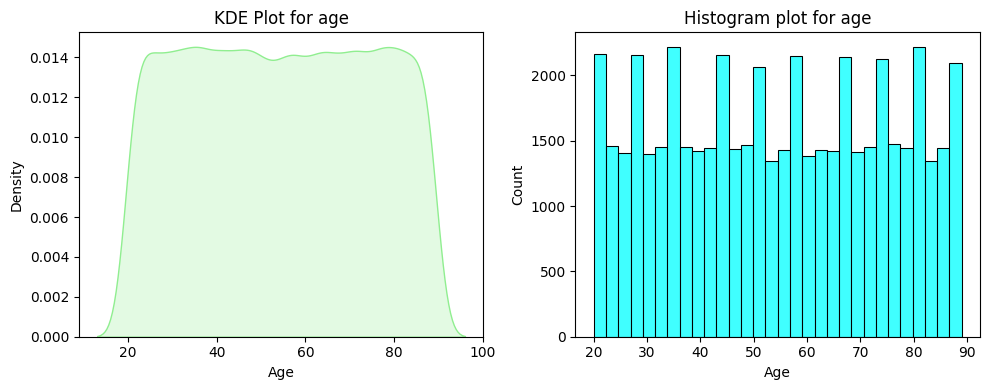

In [ ]:
# plotting for age column
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.kdeplot(data["Age"],fill=True,color="lightgreen")
plt.title("KDE Plot for age")

plt.subplot(1,2,2)
sns.histplot(data["Age"], bins=30, kde=False,color="cyan")
plt.title("Histogram plot for age")

plt.tight_layout()
plt.show()

In [ ]:
data["Age"].describe()

,Age
count,50000.000000
mean,54.421540
std,20.224451
min,20.000000
25%,37.000000
50%,54.000000
75%,72.000000
max,89.000000


In [ ]:
# INFERENCE
# range = 20 to 89 years
# mean age = 54.42 years
# standard deviation = 20.22
# interquartile range (IQR) = 37(Q1) TO 72(Q3)
#THIS SUGGESTS A BROAD REPRESENTATIVE OF BOTH YOUNG AND ELDERLY PATIENTS IN A DATASET,WHICH SUPPORTS AGE-BASED COMPARITIVE ANALYSIS

In [ ]:
# GENDER COLUMN
data["Gender"].value_counts()

,count
Gender,
Male,16796
Female,16709
Other,16495


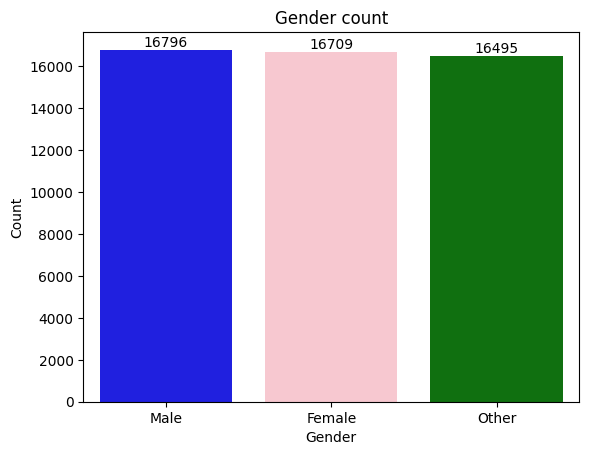

In [ ]:
sns.barplot(x = data["Gender"].value_counts().index,
            y = data["Gender"].value_counts().values,
            palette=["blue","pink","green"])
for i , v in enumerate(data["Gender"].value_counts()):
   plt.text(i,v,str(v),ha="center",va="bottom")# x position,y position,text
plt.title("Gender count")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

In [ ]:
# the dataset contains three gender categories(male,female,other) with the most common being male(16,796 records)
#gender distribution is sufficient for evaluating gender-specific survival trends and severity outcomes.

In [ ]:
# countries column
data["Country_Region"].value_counts()

,count
Country_Region,
Australia,5092
UK,5060
USA,5060
India,5040
Germany,5024
Russia,5017
Brazil,5004
Pakistan,4926
China,4913


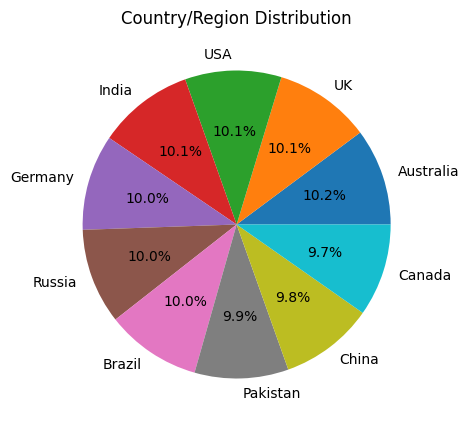

In [ ]:
# countries column
country_counts=data["Country_Region"].value_counts()
plt.figure(figsize=(5,5))
plt.pie(x=country_counts.values,
        labels=country_counts.index,
        autopct='%1.1f%%'
        )# to see the values
plt.title("Country/Region Distribution")
plt.show()

In [ ]:
country_counts

,count
Country_Region,
Australia,5092
UK,5060
USA,5060
India,5040
Germany,5024
Russia,5017
Brazil,5004
Pakistan,4926
China,4913


In [ ]:
#patients come from 10 different countries/region ,with australia being the most represented (5092 patients).number of data points for each country is almost same
#this diversity enables cross-country comparison of cancer outcomes and treatment economic

In [ ]:
#cancer type
data["Cancer_Type"].value_counts()


,count
Cancer_Type,
Colon,6376
Prostate,6308
Leukemia,6266
Liver,6249
Skin,6231
Cervical,6222
Breast,6189
Lung,6159


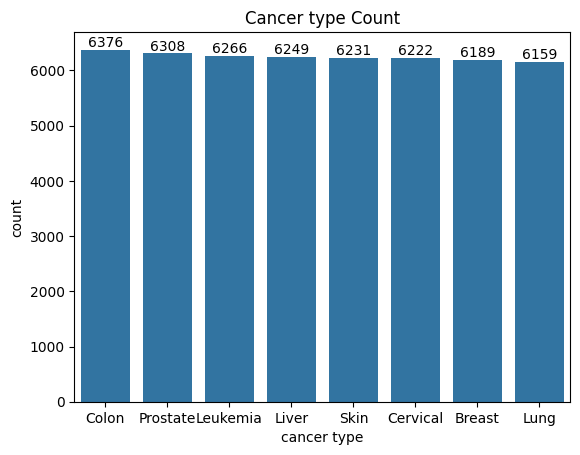

In [ ]:
sns.barplot(x = data["Cancer_Type"].value_counts().index,
            y = data["Cancer_Type"].value_counts().values)
for i , v in enumerate(data["Cancer_Type"].value_counts()):
   plt.text(i,v,str(v),ha="center",va="bottom")# x position,y position,text
plt.title("Cancer type Count")
plt.xlabel("cancer type")
plt.ylabel("count")
plt.show()


WE HAVE TOTAL 8 TYPES OF CANCER ,WITH EACH CANCER HAVING APPROX SAME NUMBER OF DATA POINTS UNDER THE LABEL,MOST COMMON CANCER ARE COLON CANCER FOLLOWED BY PROSTATE CANCER

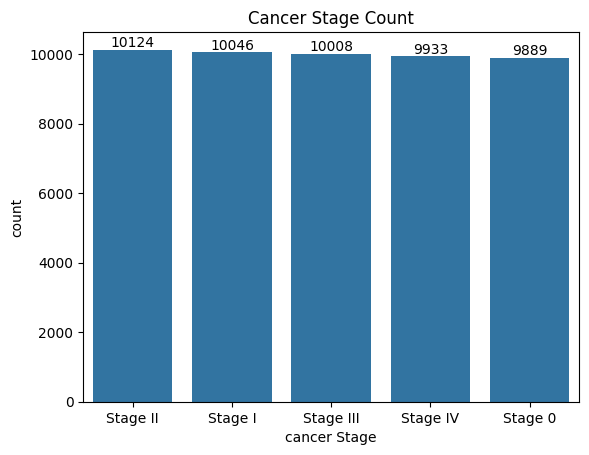

In [ ]:
#CANCER STAGE
data["Cancer_Stage"].value_counts()
sns.barplot(x = data["Cancer_Stage"].value_counts().index,
            y = data["Cancer_Stage"].value_counts().values)
for i , v in enumerate(data["Cancer_Stage"].value_counts()):
   plt.text(i,v,str(v),ha="center",va="bottom")# x position,y position,text
plt.title("Cancer Stage Count")
plt.xlabel("cancer Stage")
plt.ylabel("count")
plt.show()

CANCER STAGE HAVE 5 STAGES WITH VALUES RANGING FROM 0 TO 4,WITH 2 THE MOST COMMON ONE,AND EACH STAGE HAVE ALMOST SAME NUMBER OF DATA POINTS UNDER ITS LEVEL

In [ ]:
#plotting for treatment cost
data["Treatment_Cost_USD"]
#since it is continuous we make kde plot and hist plot

,Treatment_Cost_USD
0,62913.44
1,12573.41
2,6984.33
3,67446.25
4,77977.12
...,...
49995,71463.70
49996,49619.66
49997,5338.25
49998,45100.47


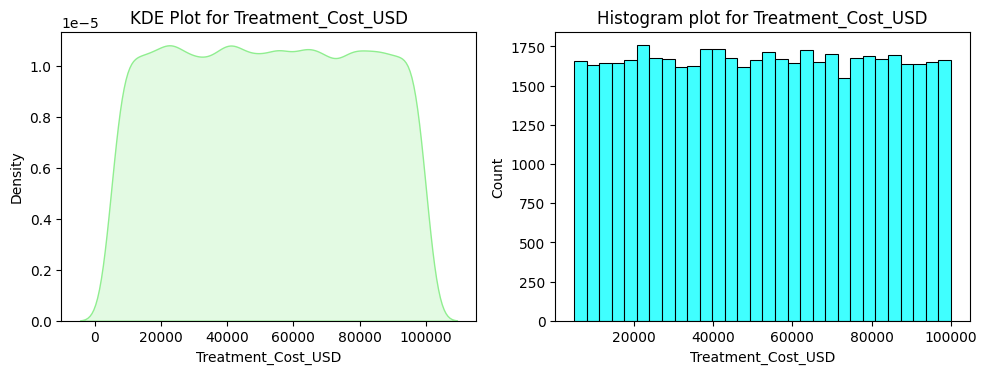

In [ ]:
# plotting for age column
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.kdeplot(data["Treatment_Cost_USD"],fill=True,color="lightgreen")
plt.title("KDE Plot for Treatment_Cost_USD")

plt.subplot(1,2,2)
sns.histplot(data["Treatment_Cost_USD"], bins=30, kde=False,color="cyan")
plt.title("Histogram plot for Treatment_Cost_USD")

plt.tight_layout()
plt.show()

In [ ]:
data["Treatment_Cost_USD"].describe()

,Treatment_Cost_USD
count,50000.000000
mean,52467.298239
std,27363.229379
min,5000.050000
25%,28686.225000
50%,52474.310000
75%,76232.720000
max,99999.840000


TREATMENT COST USD HAVE NO SKEWNESS AND THERE ARE ALMOST SAME NO OF DATAPOINTS UNDER EACH BIN AS OBSERVED BY HISTOGRAM

In [ ]:
#ANALYZING MY RISK FACTORS
data.columns

Index(['Patient_ID', 'Age', 'Gender', 'Country_Region', 'Year', 'Genetic_Risk',
       'Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level',
       'Cancer_Type', 'Cancer_Stage', 'Treatment_Cost_USD', 'Survival_Years',
       'Target_Severity_Score'],
      dtype='object')

In [ ]:
columns_of_interest=['Genetic_Risk',
       'Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level']# here we convert it into a list
summary = data[columns_of_interest].agg(["mean","std","min","max"])
summary

,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level
mean,5.001698,5.010126,5.010880,4.989826,4.991176
std,2.885773,2.888399,2.888769,2.881579,2.894504
min,0.000000,0.000000,0.000000,0.000000,0.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000


THESE VARIABLES HAVE NEARLY IDENTICAL MEAN AND STANDARD DEVIATIONS,INDICATING THEY WERE LIKELY DESIGNED ON SAME STANDARIZED SCALE.THEY ARE ESSENTIAL IN STUDYING INTERACTIONS EFFECTS (EG ,GENTIC RISK * SMOKING) ON SURVIVAL.

**bold text**  DETERMINE THE RELATIONSHIP BETWEEN RISK FACTORS AND CANCER SEVERITY

In [ ]:
from scipy.stats import linregress # it is used to plot linear regression #slope, intercept, r_value, p_value, std_err = linregress(x, y) # it return these 5 values
risk_factors =['Genetic_Risk',	'Air_Pollution',	'Alcohol_Use',	'Smoking',	'Obesity_Level']
titles=['Genetic Risk',	'Air Pollution',	'Alcohol Use',	'Smoking',	'Obesity Level']
colors=["blue","green","orange","red","purple"]

for i ,(risk_factor,title,color) in enumerate(zip(risk_factors,titles,colors),1):# 1 is added so that it will be started from 1
  print(title)
  print(color)
  print(i)# this code combines each of these and then assign a number and give result#zip converts into tuples

Genetic Risk
blue
1
Air Pollution
green
2
Alcohol Use
orange
3
Smoking
red
4
Obesity Level
purple
5


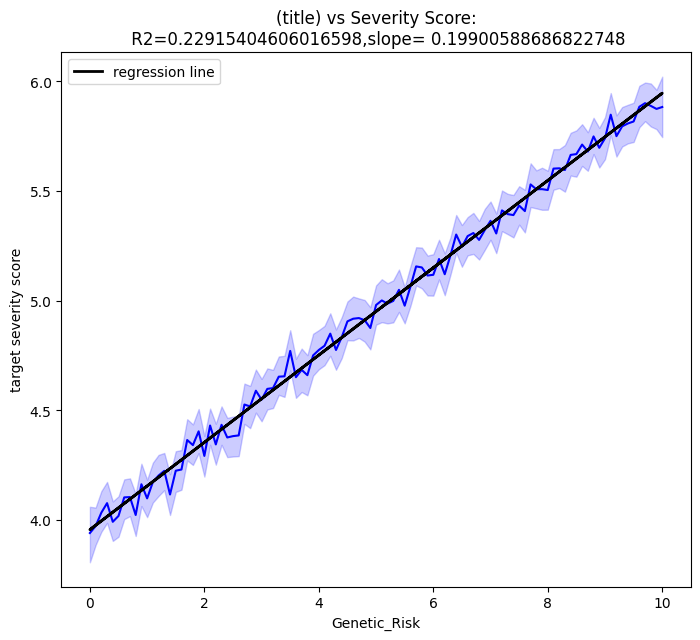

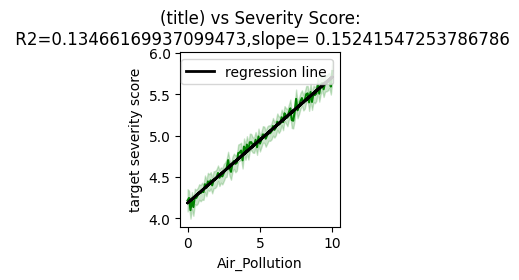

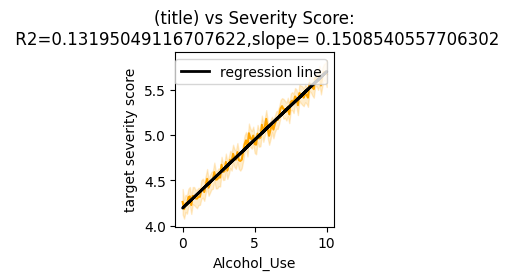

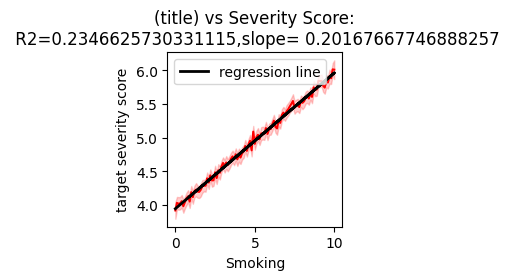

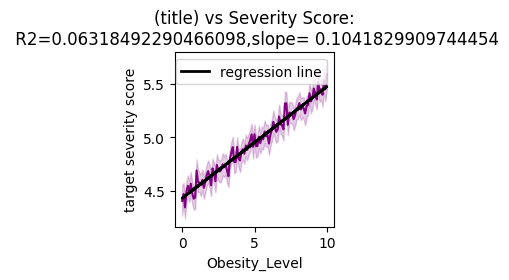

In [ ]:
plt.figure(figsize=(20,12))
for i ,(risk_factor,title,color) in enumerate(zip(risk_factors,titles,colors),1):
  plt.subplot(2,3,i)
  x =data[risk_factor]
  y =data["Target_Severity_Score"]
  slope,intercept,r_value,p_value,std_error=linregress(x,y)
  r_squared=r_value**2

  sns.lineplot(x=risk_factor ,y="Target_Severity_Score",data=data, color=color)
  plt.plot(x,x*slope+intercept, color="black",linewidth=2, label="regression line")
  plt.title(f"(title) vs Severity Score:\n R2={r_squared},slope= {slope}")
  plt.xlabel(risk_factor)
  plt.ylabel("target severity score")
  plt.legend()
  plt.tight_layout()
  plt.show()

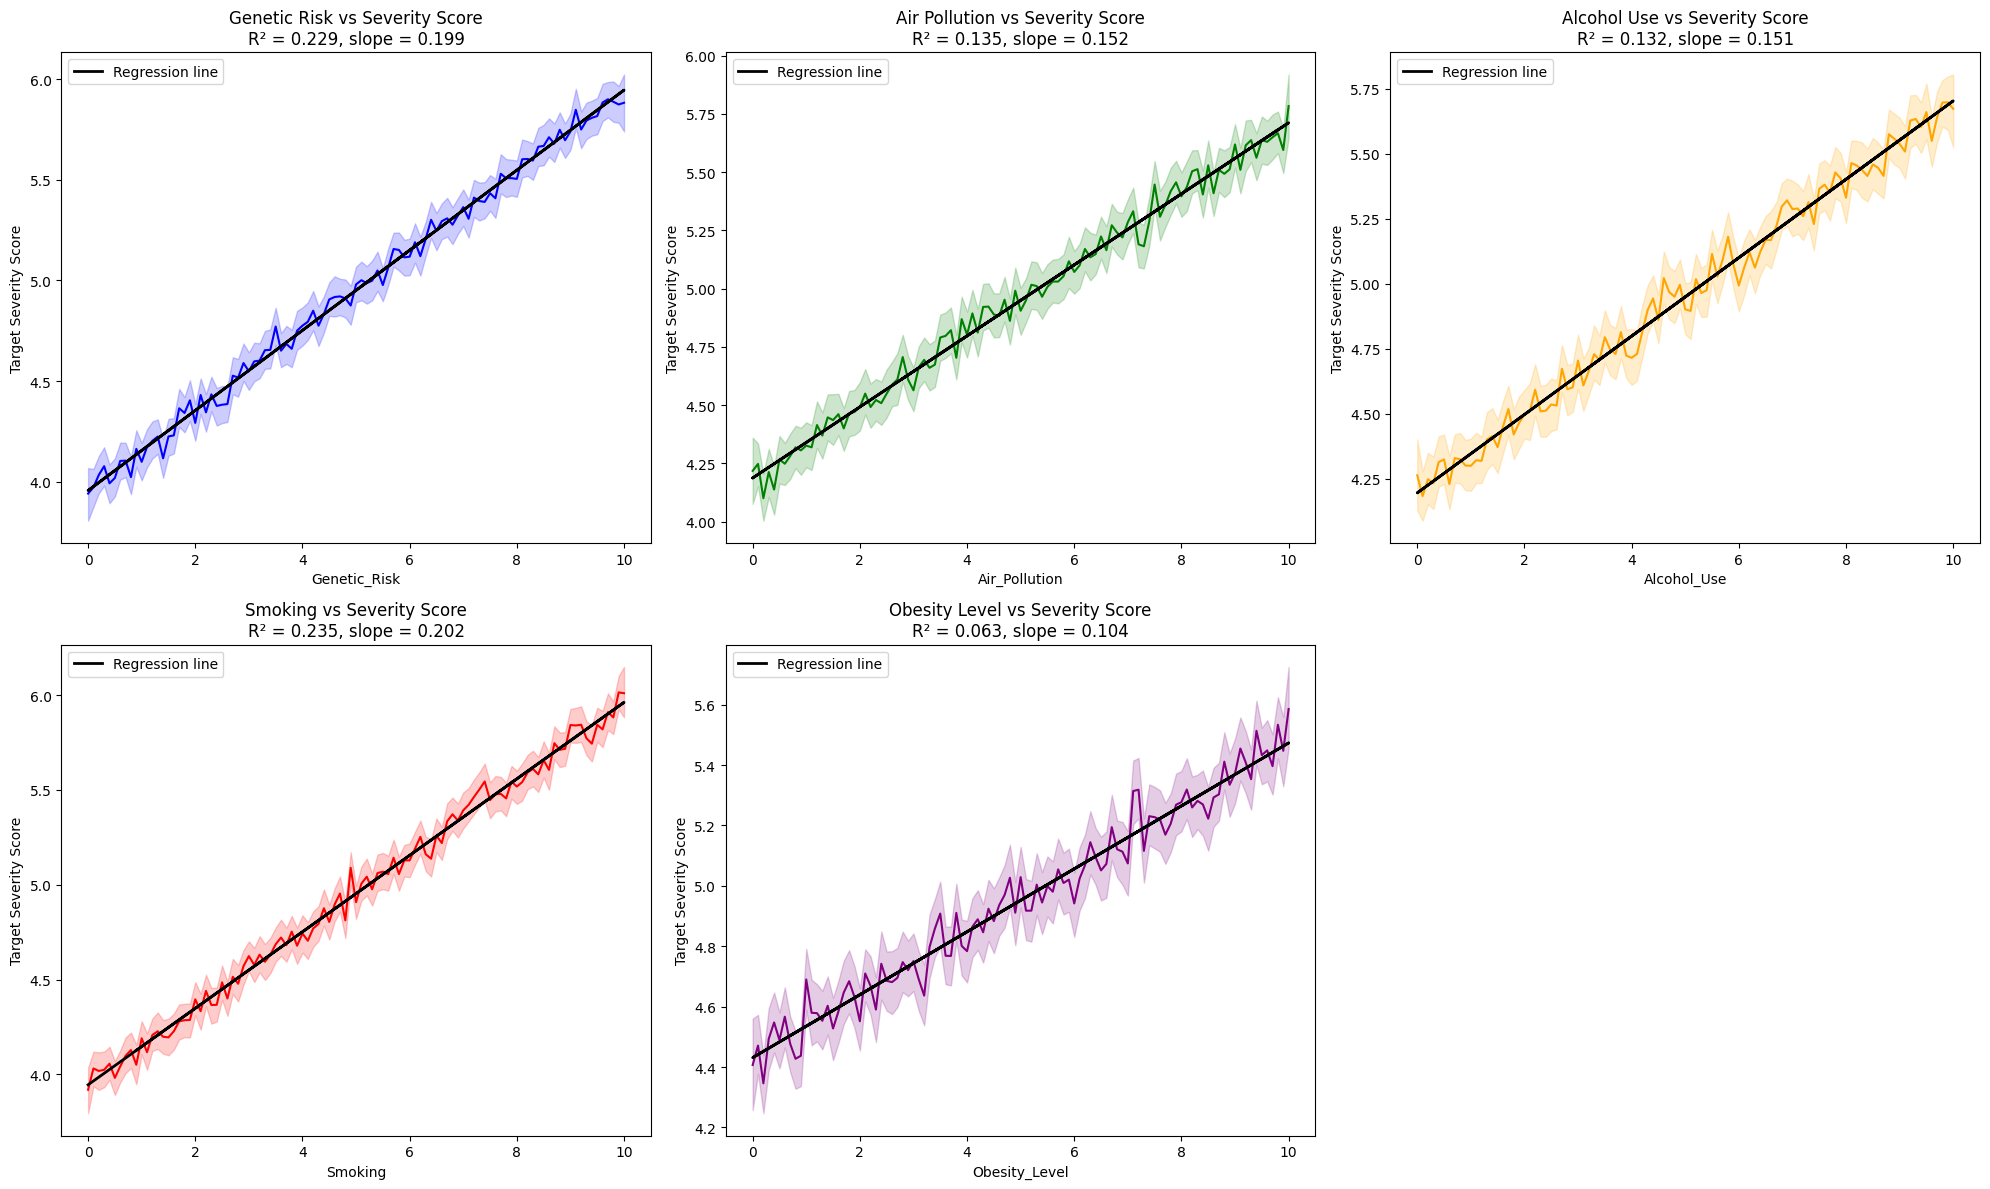

In [ ]:
plt.figure(figsize=(20, 12))

for i, (risk_factor, title, color) in enumerate(zip(risk_factors, titles, colors), 1):

    # 🔹 CLEAN DATA (fix NaN issue)
    df = data[[risk_factor, "Target_Severity_Score"]].dropna()

    if df.empty:
        print(f"{risk_factor}: no valid data")
        continue

    x = df[risk_factor]
    y = df["Target_Severity_Score"]

    # 🔹 CHECK VARIATION (fix zero-variance issue)
    if x.nunique() <= 1:
        print(f"{risk_factor}: constant variable → regression not possible")
        continue

    # 🔹 REGRESSION
    slope, intercept, r_value, p_value, std_error = linregress(x, y)
    r_squared = r_value ** 2

    plt.subplot(2, 3, i)

    sns.lineplot(x=risk_factor, y="Target_Severity_Score", data=df, color=color)
    plt.plot(x, slope * x + intercept, color="black", linewidth=2, label="Regression line")

    plt.title(f"{title} vs Severity Score\nR² = {r_squared:.3f}, slope = {slope:.3f}")
    plt.xlabel(risk_factor)
    plt.ylabel("Target Severity Score")
    plt.legend()

plt.tight_layout()
plt.show()


tounderstand the contribution of various risk factors to cancer severity ,line plots are generated for five primary variables:Genetic risk,air pollution,alcohol use,smoking,and obesity level,plotted against target severity score.

genetic risk vs target severity score
R^2 = 0.23:
A weak linear relationship,only 23 percent of the variability is target_severity_score can be explained
by genetic_risk.this suggest that other factors likely play a larger role in influencing the severity score.
slope=0.20:
a positive slope indicates that as Gentic_risk increases,the target_severity_score also tends to increase.for each unit increase in genetic risk,the target  severity score increases by 0.20 units.however because the R^2 is relatively low,this trend is not very consistent across the data.

Air pollution vs Target Severity Score
R^2=0.13
a very weak relationship.only 13 percent of the variance in Target_Severity_score can be explained by Air pollution,meaning that the factor has a limited effect on target variable.
slope=0.15:
a positive slope means that air population increases,the severity score slightly increases.but,due to low R^2,the relationship is weak and unreliable as a predictor for the target severity.

Alcohol use vs target severity score
R^2= 0.13:
similarly,the relationship between alcohol_use and target_severity_scoreis also weak.only 13 percent of the variation in the target score is explained by alcohol use.
slope=0.15:
this positive slope indicates that increased alcohol use correlates with a slight increase in target severity.However, like  airpollution ,the weak R^2 suggests other factors have a much stronger influence on the target.

smoking vs Target Severity score
R^2= 0.23:
A weak relationship ,similar to Genetic_risk.smoking explains only 23 percent of the variance in the target score,leaving the majority of the variation to be explained by other factors.
slope=0.20:
the positive slope implies that as smoking increases,the target severity score increases as well.this relationship is similar to that of gentic risk,but with a weak linear association(low R^2)

obesity level vs target severity score
R^2 = 0.06:
the weakest relationship among all factors .only 6 percent of the variation in the target score is explained by obesity level,suggesting that obesity has a minimal effect on target variable
slope = 0.10:
a positive slope,indicating a slight ,increase in the severity score as obesitylevel increases.however,due to the very low R^2,this is a weak and unreliable relationship

In [ ]:
#key takeaways

#Weak Linear Relationships:
# the R^2 values for all risk factors are relativelylow,rangingfrom 0.06 to 0.23.this indicates that while there is some relatonship between theserisk factors and target severity score,itis weak.thezse factors alonedo not explain muchof the variation in target variable.

#positive trends:
# all the slope values are positive,suggesting that As each rik factor increases,the target severity score tend to increase as well.however,because the R^2 values are low,this increase is not strongly consistent acrtoss data points.

#other influences
#the low R^2 values imply that other,unmeasured factors are likely contributing to the variationin target severity score.the risk factors you examined are only weakly correlated with the targetand are not reliable predictors on their own.

#next steps
#given the weak explanatorypower of these individual factors,it might be useful to explore other variables or more complex models that could account for more of the variation in the target severity score.this could include interactions  between risk factors,adding new features,applying more sophisticated regression techniques

ANALYZE THE PROPORTION OF EARLY-STAGE DIAGNOSES BY CANCER TYPE

In [ ]:
# 0 and 1 are termed as early stages

In [ ]:
data["Cancer_Type"].unique()

array(['Lung', 'Leukemia', 'Breast', 'Colon', 'Skin', 'Cervical',
       'Prostate', 'Liver'], dtype=object)

In [ ]:
Stage_count = data[data["Cancer_Type"]=="Lung"]["Cancer_Stage"].value_counts()

In [ ]:
Stage_count

,count
Cancer_Stage,
Stage II,1298
Stage IV,1286
Stage III,1208
Stage 0,1185
Stage I,1182


In [ ]:
early_Stage_sum = Stage_count.get("Stage 0",0) + Stage_count.get("Stage I",0)

In [ ]:
early_Stage_sum

np.int64(2367)

In [ ]:
early_Stage_sum = Stage_count.get("Stage 0",0) + Stage_count.get("Stage I", 0)
early_Stage_sum


np.int64(2367)

In [ ]:
Stage_count.sum()

np.int64(6159)

In [ ]:
total_sum = Stage_count.sum()

In [ ]:
proportion= (early_Stage_sum/total_sum)*100
print(f"proportion of lung cancer diagnosed at stage 0 and stage 1:{proportion}")

proportion of lung cancer diagnosed at stage 0 and stage 1:38.43156356551388


In [ ]:
Stage_count = data[data["Cancer_Type"]=="Leukemia"]["Cancer_Stage"].value_counts()
early_Stage_sum = Stage_count.get("Stage 0",0) + Stage_count.get("Stage I", 0)
total_sum = Stage_count.sum()
proportion= (early_Stage_sum/total_sum)*100
print(f"proportion of lung cancer diagnosed at stage 0 and stage 1:{proportion}")

proportion of lung cancer diagnosed at stage 0 and stage 1:39.53080114905841


In [ ]:
Stage_count = data[data["Cancer_Type"]=="Breast"]["Cancer_Stage"].value_counts()
early_Stage_sum = Stage_count.get("Stage 0",0) + Stage_count.get("Stage I", 0)
total_sum = Stage_count.sum()
proportion= (early_Stage_sum/total_sum)*100
print(f"proportion of lung cancer diagnosed at stage 0 and stage 1:{proportion}")

proportion of lung cancer diagnosed at stage 0 and stage 1:39.47325900791727


In [ ]:
Stage_count = data[data["Cancer_Type"]=="Colon"]["Cancer_Stage"].value_counts()
early_Stage_sum = Stage_count.get("Stage 0",0) + Stage_count.get("Stage I", 0)
total_sum = Stage_count.sum()
proportion= (early_Stage_sum/total_sum)*100
print(f"proportion of lung cancer diagnosed at stage 0 and stage 1:{proportion}")

proportion of lung cancer diagnosed at stage 0 and stage 1:40.41718946047679


In [ ]:
Stage_count = data[data["Cancer_Type"]=="Skin"]["Cancer_Stage"].value_counts()
early_Stage_sum = Stage_count.get("Stage 0",0) + Stage_count.get("Stage I", 0)
total_sum = Stage_count.sum()
proportion= (early_Stage_sum/total_sum)*100
print(f"proportion of lung cancer diagnosed at stage 0 and stage 1:{proportion}")

proportion of lung cancer diagnosed at stage 0 and stage 1:40.41084898090194


In [ ]:
Stage_count = data[data["Cancer_Type"]=="Cervical"]["Cancer_Stage"].value_counts()
early_Stage_sum = Stage_count.get("Stage 0",0) + Stage_count.get("Stage I", 0)
total_sum = Stage_count.sum()
proportion= (early_Stage_sum/total_sum)*100
print(f"proportion of lung cancer diagnosed at stage 0 and stage 1:{proportion}")

proportion of lung cancer diagnosed at stage 0 and stage 1:39.85856637737062


In [ ]:
Stage_count = data[data["Cancer_Type"]=="Prostate"]["Cancer_Stage"].value_counts()
early_Stage_sum = Stage_count.get("Stage 0",0) + Stage_count.get("Stage I", 0)
total_sum = Stage_count.sum()
proportion= (early_Stage_sum/total_sum)*100
print(f"proportion of lung cancer diagnosed at stage 0 and stage 1:{proportion}")

proportion of lung cancer diagnosed at stage 0 and stage 1:40.187064045656314


In [ ]:
Stage_count = data[data["Cancer_Type"]=="Liver"]["Cancer_Stage"].value_counts()
early_Stage_sum = Stage_count.get("Stage 0",0) + Stage_count.get("Stage I", 0)
total_sum = Stage_count.sum()
proportion= (early_Stage_sum/total_sum)*100
print(f"proportion of lung cancer diagnosed at stage 0 and stage 1:{proportion}")

proportion of lung cancer diagnosed at stage 0 and stage 1:40.614498319731155


In [ ]:
# the analysis demonstrates that early-stage diagnosis for various cancer types is relatively widespread ,with most cancers having an early stage diagnosis rate between 38.43 to 40.61 percent.liver cancer shows the highest proprtion ,while lung cancer shows the lowest.these findings suggest that while screening and diagnostic methods are effective .improvements can still be made ,particularly in lung cancer detection.

# further research into screening strategies ,early intervention and the use of advanced diagnostic technologies could help increase the proportion of early stage diagnosis ,ultimately leading to better survival rates and outcomes for cancer patients.the relatvely small variation across the cancer types indicate that in general healthcare systemsmay need to focus on enhancing early detection uniformly,with targeted efforts to address specific gaps in detection ,particularly for cancers like lung cancer

IDENTIFY KEY PREDICTORS OF CANCER SEVERITY AND SURVIVAL YEARS

In [ ]:
features=["Age","Genetic_Risk","Air_Pollution","Alcohol_Use","Smoking","Obesity_Level"]
targets=["Survival_Years","Target_Severity_Score"]
#calculate correlations
pearson_corr=data[features+targets].corr(method="pearson")
spearman_corr=data[features+targets].corr(method="spearman")

In [ ]:
pearson_corr

,Age,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Survival_Years,Target_Severity_Score
Age,1.000000,0.002229,0.001101,-0.004130,0.001734,-0.002706,-0.000147,-0.001481
Genetic_Risk,0.002229,1.000000,-0.004492,-0.002558,-0.003718,0.003522,0.001708,0.478700
Air_Pollution,0.001101,-0.004492,1.000000,0.003511,0.003549,0.006507,0.000893,0.366963
Alcohol_Use,-0.004130,-0.002558,0.003511,1.000000,-0.002938,0.007425,-0.000527,0.363250
Smoking,0.001734,-0.003718,0.003549,-0.002938,1.000000,0.005828,0.001371,0.484420
Obesity_Level,-0.002706,0.003522,0.006507,0.007425,0.005828,1.000000,0.009771,0.251366
Survival_Years,-0.000147,0.001708,0.000893,-0.000527,0.001371,0.009771,1.000000,0.004161
Target_Severity_Score,-0.001481,0.478700,0.366963,0.363250,0.484420,0.251366,0.004161,1.000000


In [ ]:
spearman_corr

,Age,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Survival_Years,Target_Severity_Score
Age,1.000000,0.002207,0.001102,-0.004133,0.001692,-0.002732,-0.000149,-0.002076
Genetic_Risk,0.002207,1.000000,-0.004472,-0.002571,-0.003707,0.003494,0.001684,0.472193
Air_Pollution,0.001102,-0.004472,1.000000,0.003507,0.003561,0.006496,0.000841,0.357528
Alcohol_Use,-0.004133,-0.002571,0.003507,1.000000,-0.002904,0.007401,-0.000543,0.354694
Smoking,0.001692,-0.003707,0.003561,-0.002904,1.000000,0.005838,0.001372,0.477881
Obesity_Level,-0.002732,0.003494,0.006496,0.007401,0.005838,1.000000,0.009780,0.243152
Survival_Years,-0.000149,0.001684,0.000841,-0.000543,0.001372,0.009780,1.000000,0.003431
Target_Severity_Score,-0.002076,0.472193,0.357528,0.354694,0.477881,0.243152,0.003431,1.000000


In [ ]:
pearson_corr[targets]

,Survival_Years,Target_Severity_Score
Age,-0.000147,-0.001481
Genetic_Risk,0.001708,0.478700
Air_Pollution,0.000893,0.366963
Alcohol_Use,-0.000527,0.363250
Smoking,0.001371,0.484420
Obesity_Level,0.009771,0.251366
Survival_Years,1.000000,0.004161
Target_Severity_Score,0.004161,1.000000


In [ ]:
features=["Age","Genetic_Risk","Air_Pollution","Alcohol_Use","Smoking","Obesity_Level"]
targets=["Survival_Years","Target_Severity_Score"]
#calculate correlations
pearson_corr=data[features+targets].corr(method="pearson")
spearman_corr=data[features+targets].corr(method="spearman")
#slice out only the relationship with target variables
pearson_results=pearson_corr[targets]
spearman_results=spearman_corr[targets]

#combine both
correlation_df=pd.concat([pearson_results,spearman_results],axis=1,keys=["pearson","spearman"])
correlation_df


pearson                             spearman  \
                      Survival_Years Target_Severity_Score Survival_Years   
Age                        -0.000147             -0.001481      -0.000149   
Genetic_Risk                0.001708              0.478700       0.001684   
Air_Pollution               0.000893              0.366963       0.000841   
Alcohol_Use                -0.000527              0.363250      -0.000543   
Smoking                     0.001371              0.484420       0.001372   
Obesity_Level               0.009771              0.251366       0.009780   
Survival_Years              1.000000              0.004161       1.000000   
Target_Severity_Score       0.004161              1.000000       0.003431   

                                             
                      Target_Severity_Score  
Age                               -0.002076  
Genetic_Risk                       0.472193  
Air_Pollution                      0.357528  
Alcohol_Use                        0.354694  
Smoking                            0.477881  
Obesity_Level                      0.243152  
Survival_Years                     0.003431  
Target_Severity_Score              1.000000

CORRELATION WITH TARGET SEVERITY SCORE
FEATURE     PEARSON     SPEARMAN        INTERPRETATION

SMOKING     0.484        0.478          STRONG POSITIVE CORRELATION.HIGHER
                                        SMOKING LEVELS ARE ASSOCIATED WITH HIGHER SEVERITY SCORES

GENETIC     0.479        0.472          STRONG POSITIVE CORRELATION.GENETIC
RISK                                    PREDISPOSITION IS A SIGNIFICANT
                                        FACTOR IN SEVERITY

AIR         0.367        0.358          MODERATE POSITIVE CORRELATION.
POLLUTION                               SUGGESTS ENVIRONMENTAL
                                        EXPOSURE CONTRIBUTES TO SEVERITY

ALCOHOL_    0.363        0.355          MODERATE POSITIVE CORRELATION.
USE                                     ALCOHOL CONSUMPTION MAY PLAY A
                                        ROLE IN WORSENING SEVERITY

OBESITY     0.251       0.243           WEAK TO MODERATE POSITIVE
LEVEL                                   CORRELATION.THERE IS SOME
                                        ASSOCIATION BETWEEN OBESITY
                                        AND SEVERITY
                                        
TREATMENT_ -0.466      -0.459           STRONG NEGATIVE CORRELATION
COST                                    HIGHER SEVERITY COSTS TEND TO
                                        HAVE LOWER TREATMENT COSTS.WHICH MAY REFLECT HEALTHCARE ACCESS ISSUES OR LATE STGE DIGNOSIS
                                        LIMITING TREATMENT     










                                      


In [ ]:
# FEATURES    PEARSON      SPEARMAN          INTERPRETATION
  ALL         0.00         0.00               NEGLIGIBLE FOR NO CORRELATION.THESE VARIABLES DO NOT SHOW ANY SIGNIFICANT LINEAR OR MONOTONIC ASSOCIATION WITH SURVIVAL DURATION
  FEATURES

In [ ]:
# RANDOM FOREST FOR  TARGET SEVERITY SCORE
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score

# converting categorical columns to numerical columns
categorical_cols=["Gender","Country_Region","Cancer_Type","Cancer_Stage"]
for col in categorical_cols:
  le=LabelEncoder()
  data[col]=le.fit_transform(data[col])

# preparing features and input
X= data.drop(columns=["Patient_ID","Survival_Years","Target_Severity_Score","Treatment_Cost_USD"])
y_severity= data["Target_Severity_Score"]

# train test split
X_train_s,X_test_s,y_train_s,y_test_s=train_test_split(X,y_severity,test_size=0.2,random_state=42)

# train the model
model=RandomForestRegressor(n_estimators=200,max_depth=None,min_samples_split=2,min_samples_leaf=1,random_state=42)
model.fit(X_train_s,y_train_s)

#evluate the model
train_r2_severity=r2_score(y_train_s ,model.predict(X_train_s))
test_r2_severity=r2_score(y_test_s ,model.predict(X_test_s))

In [ ]:
data
# here the data that is Gender","Country_Region","Cancer_Type","Cancer_Stage" is being converted to numerical data

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,1,8,2021,6.4,2.8,9.5,0.9,8.7,5,3,62913.44,5.9,4.92
1,PT0000001,34,1,3,2021,1.3,4.5,3.7,3.9,6.3,3,0,12573.41,4.7,4.65
2,PT0000002,80,1,6,2023,7.4,7.9,2.4,4.7,0.1,0,2,6984.33,7.1,5.84
3,PT0000003,40,1,8,2015,1.7,2.9,4.8,3.5,2.7,2,1,67446.25,1.6,3.12
4,PT0000004,43,0,1,2017,5.1,2.8,2.3,6.7,0.5,7,3,77977.12,2.9,3.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,PT0049995,80,1,6,2023,2.3,7.5,2.8,3.8,2.9,3,0,71463.70,1.0,3.63
49996,PT0049996,40,0,9,2018,6.4,3.5,2.9,9.0,9.8,2,1,49619.66,0.4,6.03
49997,PT0049997,74,1,6,2015,6.2,1.6,8.7,4.7,4.0,0,0,5338.25,2.7,6.02
49998,PT0049998,21,1,1,2018,4.0,6.5,7.6,8.6,8.1,4,4,45100.47,7.5,6.54


In [ ]:
print(train_r2_severity)
print(test_r2_severity)

0.9689886894803543
0.7683892517466495


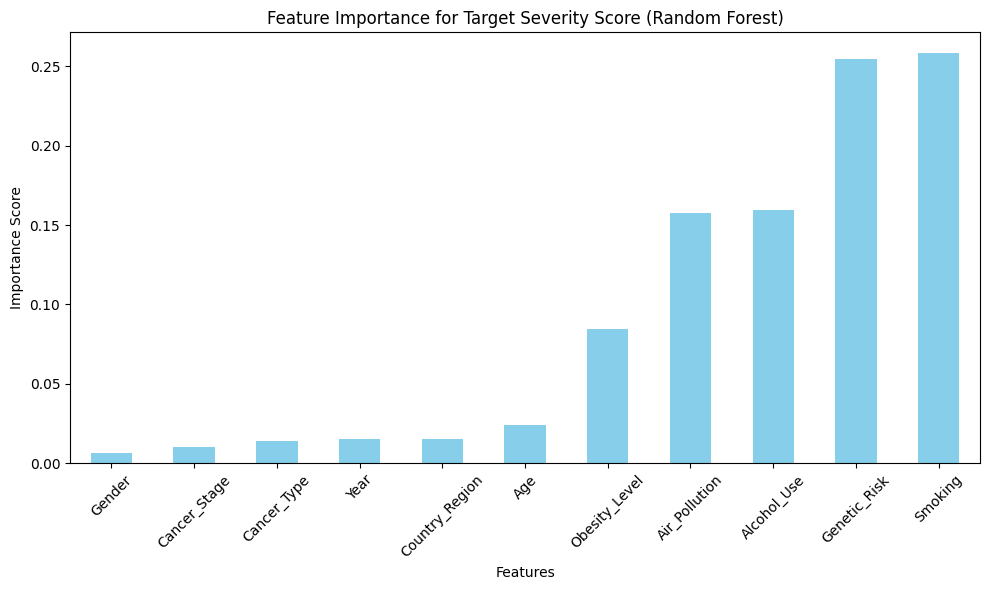

In [ ]:
feature_importance_severity=pd.Series(model.feature_importances_,index=X.columns).sort_values(ascending=True)
#plotting of important features
plt.figure(figsize=(10,6))
feature_importance_severity.plot(kind="bar",color="skyblue")
plt.title("Feature Importance for Target Severity Score (Random Forest)")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# feature importance interpretation
# smoking 0.2336  most important predictor of severity score.the more patient smokes ,the higher their severity tends to be.
# genetic risk  0.2286 strong genetic predisposition is nearly as important as smoking
# treatment cost usd 0.2133 higher treatment cost are associated with more severe conditions
# alcohol use 0.1291 alcohol also plays a significant role
# air pollution 0.1271 environmental factor-patients in more polluted area have worse severity scores
# obesity level 0.0573 has an effect ,but much smaller
# age to gender < 0.01 very low importance; these dont explain much variation in severity scores

In [ ]:
# RANDOM FOREST FOR  SURVIVAL YEARS
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score

# converting categorical columns to numerical columns
categorical_cols=["Gender","Country_Region","Cancer_Type","Cancer_Stage"]
for col in categorical_cols:
  le=LabelEncoder()
  data[col]=le.fit_transform(data[col])

# preparing features and input
X= data.drop(columns=["Patient_ID","Survival_Years","Target_Severity_Score","Treatment_Cost_USD"])
y_severity= data["Survival_Years"]

# train test split
X_train_s,X_test_s,y_train_s,y_test_s=train_test_split(X,y_severity,test_size=0.2,random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5,10,None],
    'min_samples_split': [2,5],
    'min_samples_leaf': [1, 2]
}
# train the model
model=RandomForestRegressor(random_state=40)
GSC=GridSearchCV(model , param_grid, cv=3, scoring="r2",n_jobs=-1)
GSC.fit(X_train_s,y_train_s)

best_rf_severity=GSC.best_estimator_


#evluate the model
train_r2_severity=r2_score(y_train_s ,best_rf_severity.predict(X_train_s))
test_r2_severity=r2_score(y_test_s ,best_rf_predict(X_test_s))












KeyboardInterrupt: 

In [ ]:
print(train_r2_severity)
print(test_r2_severity)

NameError: name 'train_r2_severity' is not defined

In [ ]:
# here r2 score is coming negative and so it is very less

<Axes: xlabel='Survival_Years', ylabel='Count'>

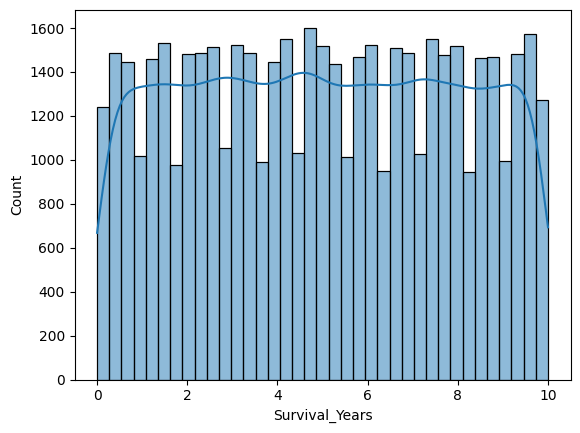

In [ ]:
import seaborn as sns
sns.histplot(data["Survival_Years"],kde=True)

In [ ]:
data.corr(numeric_only=True)["Survival_Years"].sort_values(ascending = True)
# its basically pearson correlation coeffiient

,Survival_Years
Gender,-0.007121
Cancer_Stage,-0.003014
Cancer_Type,-0.001717
Alcohol_Use,-0.000527
Treatment_Cost_USD,-0.000429
Age,-0.000147
Year,0.000018
Air_Pollution,0.000893
Smoking,0.001371
Genetic_Risk,0.001708


In [ ]:
# the information in our column does not help the model figure out how long someone will survive

In [ ]:
# so for doing research we have to bring new columns

QNO 3- EXPLORE THE ECONOMIC BURDEN OF CANCER TREATMENT ACROSS DIFFERENT DEMOGRAPHICS AND COUNTRIES

In [ ]:
data

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,PT0049995,80,Male,Pakistan,2023,2.3,7.5,2.8,3.8,2.9,Leukemia,Stage 0,71463.70,1.0,3.63
49996,PT0049996,40,Female,USA,2018,6.4,3.5,2.9,9.0,9.8,Colon,Stage I,49619.66,0.4,6.03
49997,PT0049997,74,Male,Pakistan,2015,6.2,1.6,8.7,4.7,4.0,Breast,Stage 0,5338.25,2.7,6.02
49998,PT0049998,21,Male,Brazil,2018,4.0,6.5,7.6,8.6,8.1,Liver,Stage IV,45100.47,7.5,6.54


In [ ]:
df=data.copy()

In [ ]:
df

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,PT0049995,80,Male,Pakistan,2023,2.3,7.5,2.8,3.8,2.9,Leukemia,Stage 0,71463.70,1.0,3.63
49996,PT0049996,40,Female,USA,2018,6.4,3.5,2.9,9.0,9.8,Colon,Stage I,49619.66,0.4,6.03
49997,PT0049997,74,Male,Pakistan,2015,6.2,1.6,8.7,4.7,4.0,Breast,Stage 0,5338.25,2.7,6.02
49998,PT0049998,21,Male,Brazil,2018,4.0,6.5,7.6,8.6,8.1,Liver,Stage IV,45100.47,7.5,6.54


In [ ]:
country_gender_cost=data.groupby(["Country_Region","Gender"])["Treatment_Cost_USD"].mean().reset_index()

In [ ]:
#convert age column to bins
data["Age_Group"]=pd.cut(data["Age"],bins=[0,30,45,60,75,100],labels=["0-30","31-45","46-60","61-75","76+"])

In [ ]:
data

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score,Age_Group
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92,61-75
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65,31-45
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84,76+
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12,31-45
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62,31-45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,PT0049995,80,Male,Pakistan,2023,2.3,7.5,2.8,3.8,2.9,Leukemia,Stage 0,71463.70,1.0,3.63,76+
49996,PT0049996,40,Female,USA,2018,6.4,3.5,2.9,9.0,9.8,Colon,Stage I,49619.66,0.4,6.03,31-45
49997,PT0049997,74,Male,Pakistan,2015,6.2,1.6,8.7,4.7,4.0,Breast,Stage 0,5338.25,2.7,6.02,61-75
49998,PT0049998,21,Male,Brazil,2018,4.0,6.5,7.6,8.6,8.1,Liver,Stage IV,45100.47,7.5,6.54,0-30


In [ ]:
country_age_cost=data.groupby(["Country_Region","Age_Group"])["Treatment_Cost_USD"].mean().reset_index()

In [ ]:
country_age_cost

,Country_Region,Age_Group,Treatment_Cost_USD
0,Australia,0-30,53315.916090
1,Australia,31-45,52290.210149
2,Australia,46-60,50887.310424
3,Australia,61-75,51827.812279
4,Australia,76+,54922.283170
5,Brazil,0-30,53814.974610
6,Brazil,31-45,53178.611181
7,Brazil,46-60,52650.893070
8,Brazil,61-75,51854.086124
9,Brazil,76+,51448.451094


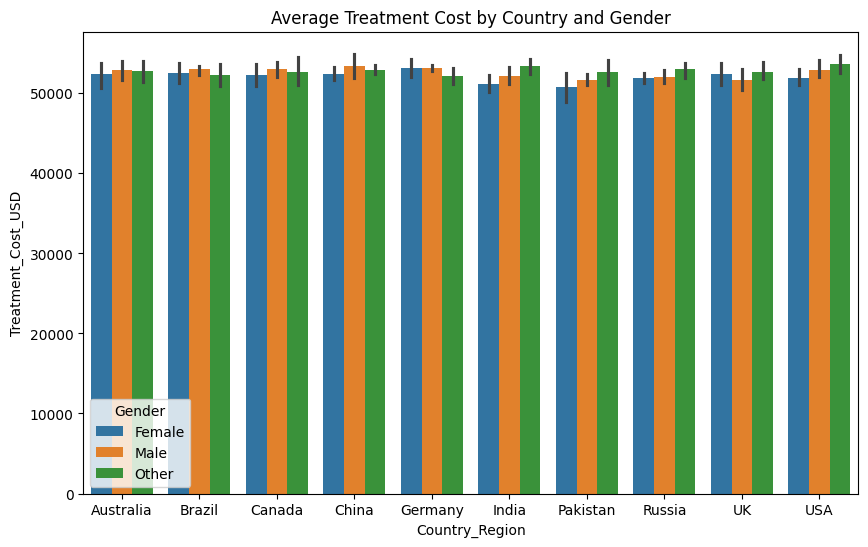

In [ ]:
country_age_cost=data.groupby(["Country_Region","Age_Group","Gender"])["Treatment_Cost_USD"].mean().reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=country_age_cost,x="Country_Region",y="Treatment_Cost_USD",hue="Gender")
plt.title("Average Treatment Cost by Country and Gender")
plt.show()



In [ ]:
country_age_cost

,Country_Region,Age_Group,Gender,Treatment_Cost_USD
0,Australia,0-30,Female,53287.701319
1,Australia,0-30,Male,52939.875035
2,Australia,0-30,Other,53776.208452
3,Australia,31-45,Female,51647.694000
4,Australia,31-45,Male,54212.453438
...,...,...,...,...
145,USA,61-75,Male,55381.892304
146,USA,61-75,Other,52070.474766
147,USA,76+,Female,51877.032768
148,USA,76+,Male,52445.346342


In [ ]:
country_age_cost=data.groupby(["Country_Region","Age_Group"])["Treatment_Cost_USD"].mean().reset_index()

In [ ]:
heatmap_data= country_age_cost.pivot(index="Age_Group",columns="Country_Region",values="Treatment_Cost_USD")

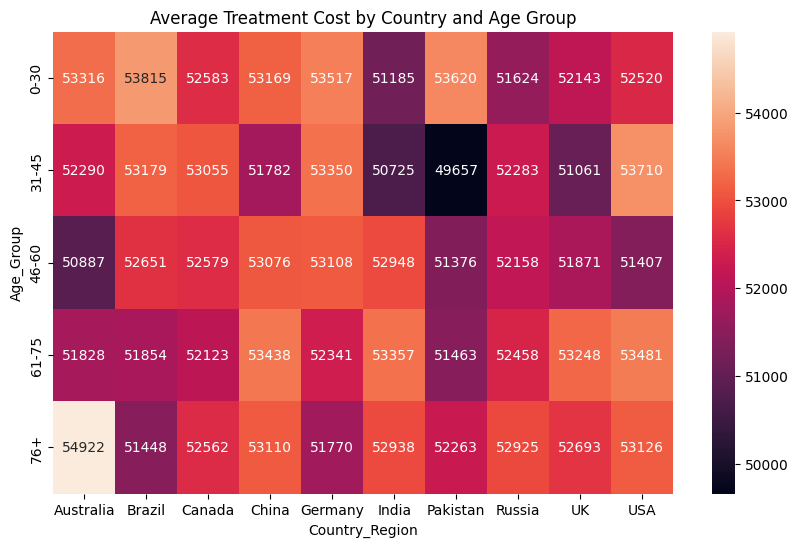

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, annot=True,fmt=".0f")
plt.title("Average Treatment Cost by Country and Age Group")
plt.show()
#

In [ ]:
# geographic disparities in economic burden
# cancer treatment costs are significantly higher in developed nations like in USA,Australia,,and china,revealing the heavy financial load in advanced healthcare sysytems.meanwhile,countries likeindia and pakistan exhibit comparitively lower costs,likelydue to lower healthcare pricing structures or limited access to advanced treatment.this highlights clear global inequality in healthcare affordability that can intensify financial strain depending on a patients country of residence

#gender based cost patterns are uniform
#across all countries ,gender based differences in average treatment costs are minimal ,suggesting no major gender bias in pricing or access to cancer care.this uniformity may reflect standardization in treatment protocols or equitable healthcare policies ,but it also points to the fact that the financial impact is universal across genders

#age-related escalation in treatment costs
# treatment costs tend to rise with age,particularly forthose aged 61 and above .this trend is especially evident in countries like australia and the USA,where older age groups face sharply higher costs.the increased financial burden in these groups could be due to more intensive care needs,multiple comorbities ,or prolonged treatments .this pattern underlinesthe vulnerability of elderly populations and the pressing need for targeted support for senior citizens.

#role of healthcare sysytems in cost variation
#countries with robust public healthcare systems such as canada,germany, and the UK-show relatively stable treatment costs such as age groups ,reflecting the benefits of healthcare subsidies or coverage. this consistency reinforces the importance of government intervention and universal healthcare in mitigating financial disparities in cancer treatment


ASSESS WHETHER HIGHER TREATMENT COST IS ASSOCIATED WITH LONGER SURVIVAL

In [ ]:
# null hypothesis (ho) :- there is no correlation between treatment cost and survival years
# alternative hypothesis(h1) :- there is a correlation (positive or negative ) between treatment cost and survival years

In [ ]:
from scipy.stats import pearsonr, spearmanr
x= data["Treatment_Cost_USD"]
y= data["Survival_Years"]

# performing pearson correlation test
pearson_corr,pearson_p = pearsonr(x,y)
print(f"Person  Correlation Coefficient: {pearson_corr:.3f}")
print(f" pearson P-value: {pearson_p:.3f}")

# performing spearmanr correlation test
spearman_corr,spearman_p = spearmanr(x,y)
print(f"Spearmanr  Correlation Coefficient: {spearman_corr:.3f}")
print(f" spearmanr P-value: {spearman_p:.3f}")

alpha=0.05

def interpret_corr(corr,p,method):
  if p<alpha:
    print(f"{method}, test: we reject the null  hypothesis")
  else:
    print(f"{method}, we failed to reject the null hypothesis")

interpret_corr(pearson_corr,pearson_p,"pearson")
interpret_corr(spearman_corr,spearman_p,"spearman")

Person  Correlation Coefficient: -0.000
 pearson P-value: 0.924
Spearmanr  Correlation Coefficient: -0.000
 spearmanr P-value: 0.921
pearson, we failed to reject the null hypothesis
spearman, we failed to reject the null hypothesis


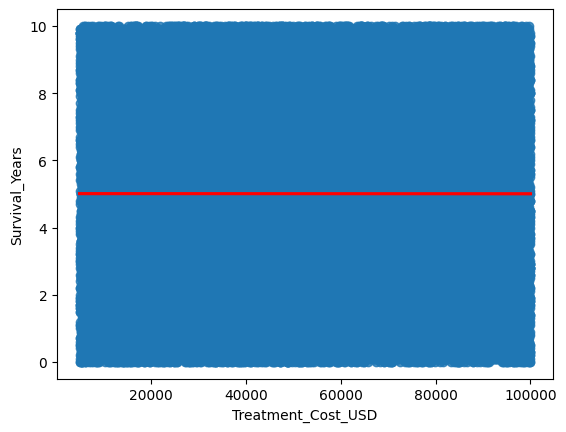

In [ ]:
sns.regplot(x=x,y=y, line_kws={"color":"red"})
plt.show()

In [ ]:
# there is no relationship between treatment cost and survival years

EVALUATE IF HIGHER CANCER STAGES LEAD TO GREATER TREATMENT COSTS AND REDUCED SURVIVAL YEARS

In [ ]:
df=data.copy()

In [ ]:
stage_order= ["stage 0","stage I","stage II","stage III","stage IV"]

In [ ]:
df.groupby("Cancer_Stage")[["Treatment_Cost_USD","Survival_Years"]].mean().reset_index()

,Cancer_Stage,Treatment_Cost_USD,Survival_Years
0,Stage 0,52572.589493,5.015199
1,Stage I,52674.079638,5.012990
2,Stage II,52082.841258,4.995170
3,Stage III,52708.197506,5.036311
4,Stage IV,52302.471041,4.972596


In [ ]:
grouped_stats= df.groupby("Cancer_Stage")[["Treatment_Cost_USD","Survival_Years"]].mean().reset_index

In [ ]:
# treatment cost vs cancer stage
# null hypothesis(Ho): the average treatment cost is the same acrosss all cancer stages
# alternative hypothesis(H1): at least one stage has a different average cost

# survival years vs cancer stage
# null hypothesis (ho): the average survival years are the same across all cancer stages
# alternative hypothesis(h1): at least one stage has a different survival duration

In [ ]:
grouped_costs=[]
grouped_survival=[]

for stage in stage_order:
  stage_data=df[df["Cancer_Stage"]==stage]
  cost=stage_data["Treatment_Cost_USD"]
  survival=stage_data["Survival_Years"]
  grouped_costs.append(cost)

3R1CD0O   grouped_survival.append(survival)

In [ ]:
grouped_costs

[Series([], Name: Treatment_Cost_USD, dtype: float64),
 Series([], Name: Treatment_Cost_USD, dtype: float64),
 Series([], Name: Treatment_Cost_USD, dtype: float64),
 Series([], Name: Treatment_Cost_USD, dtype: float64),
 Series([], Name: Treatment_Cost_USD, dtype: float64)]

In [ ]:
len(grouped_costs)



5

In [ ]:
from scipy.stats import shapiro, f_oneway

# Re-create df from the original data (which currently has string Cancer_Stage values)
# This is important because the 'data' DataFrame itself might have been label encoded in other cells.
# By creating a fresh copy from 'data' at this point (which the kernel state shows is NOT label encoded for Cancer_Stage),
# we ensure 'df' has the string stage names for this specific analysis.
df = data.copy()

# Corrected stage_order to match the exact string values in the DataFrame (e.g., 'Stage 0', 'Stage I')
# Based on previous value_counts and kernel state.
stage_order_actual = ['Stage 0', 'Stage I', 'Stage II', 'Stage III', 'Stage IV']

grouped_costs = []
grouped_survival = []

# Iterate using the actual string stage names
for stage_name in stage_order_actual:
  stage_data = df[df["Cancer_Stage"] == stage_name]
  cost = stage_data["Treatment_Cost_USD"]
  survival = stage_data["Survival_Years"]
  grouped_costs.append(cost)
  grouped_survival.append(survival)

normal_cost = 0
normal_survival = 0

for i in range(len(stage_order_actual)): # Loop over the length of the actual stage order
  # Ensure there is data in the series before running shapiro
  # Shapiro-Wilk test requires at least 3 data points.
  if len(grouped_costs[i]) >= 3:
    cost_p = shapiro(grouped_costs[i])[1] # shapiro returns (statistic, p-value)
  else:
    cost_p = 1.0 # Not enough data for meaningful test, or assume non-normal for small N

  if len(grouped_survival[i]) >= 3:
    surv_p = shapiro(grouped_survival[i])[1] # shapiro returns (statistic, p-value)
  else:
    surv_p = 1.0 # Not enough data for meaningful test, or assume non-normal for small N

  print(f"Cost Shapiro p-value for group {stage_order_actual[i]}: {cost_p:.3f}") # Use actual stage names for output clarity
  print(f"Survival Shapiro p-value for group {stage_order_actual[i]}: {surv_p:.3f}")

  if cost_p < 0.05:
    normal_cost += 1
  if surv_p < 0.05: # Corrected variable name
    normal_survival += 1

print(f"Number of cost groups that are not normally distributed (p < 0.05): {normal_cost}")
print(f"Number of survival groups that are not normally distributed (p < 0.05): {normal_survival}")


Cost Shapiro p-value for group Stage 0: 0.000
Survival Shapiro p-value for group Stage 0: 0.000
Cost Shapiro p-value for group Stage I: 0.000
Survival Shapiro p-value for group Stage I: 0.000
Cost Shapiro p-value for group Stage II: 0.000
Survival Shapiro p-value for group Stage II: 0.000
Cost Shapiro p-value for group Stage III: 0.000
Survival Shapiro p-value for group Stage III: 0.000
Cost Shapiro p-value for group Stage IV: 0.000
Survival Shapiro p-value for group Stage IV: 0.000
Number of cost groups that are not normally distributed (p < 0.05): 5
Number of survival groups that are not normally distributed (p < 0.05): 5


In [ ]:
print(normal_cost)
print(normal_survival)

5
5


In [ ]:
# here we cant use anova one way since here it is not normally distributed

In [ ]:
from scipy.stats import kruskal

In [ ]:
kruskal_cost=kruskal(*grouped_costs)
kruskal_survival=kruskal(*grouped_survival)

p_cost= kruskal_cost.pvalue
p_survival=kruskal_survival.pvalue


In [ ]:
p_cost

np.float64(0.4254451689062656)

In [ ]:
p_survival

np.float64(0.6033078729984223)

In [ ]:
# kruskal wallis test : treatment cost across cancer stages ==
# p-value=0.4254
# conclusion:no significant difference in treatment cost among cancer stages
# krsukal wallis test: survival years acrosscancer stages ===
# p value :0.6033
# conclusion: no significant difference in survival years among cancer stages

EXAMINW WHETHER HIGHER GENETIC RISK AMPLIFIES THE NEGATIVE EFFECTS OF SMOKING ON CANCER SEVERITY AND SURVIVAL OUTCOMES

In [ ]:
# NULL HYPOTHESIS
# The interaction effect between genetic risk and smoking on cancer severity is not significant
#(genetic risk does not amplify or alter affect the effect of smoking)

#ALTERNATIVE HYPOTHESIS
# the interaction effect between genetic risk and smoking opn cancer severity is significant
#(genetic risk does amplify or alter the effect of smoking)

In [ ]:
import statsmodels.formula.api as smf
model= smf.ols("Target_Severity_Score ~ Genetic_Risk*Smoking",data=data).fit()
model.summary2().tables[1].loc["Genetic_Risk:Smoking"]

,Genetic_Risk:Smoking
Coef.,-0.000228
Std.Err.,0.000471
t,-0.484187
P>|t|,0.628255
[0.025,-0.001150
0.975],0.000694


In [ ]:
p_value=0.628255

In [ ]:
# interpretation
# the interaction coefficient is negative but very small:-0.00028
# the p value = 0.628,which is greater than 0.05,so we fail to reject the null hypothesis
# conclusion(statistical):
# test used :multiple linear regression with interaction term
#null hypothesis(H0):- no interaction effect between genetic risk and smoking
#alternative hypothesis(H1):-there is an interaction effect
# the interaction effect between genetic risk and smoking on target severityscore is not statistically significant(p=0.628>0.05)
#this means that based on your data,there is no evidence that geneticrisk amplifies or reduces the effect of smoking on target severity score
# in other words,smoking and genetic risk may each have independent effects (or none),but they do not interact in a way that significantly changes the outcome